In [1]:
import pandas as pd
import random
import os
import numpy as np
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv')
train_x = train_df.drop(columns=['PRODUCT_ID','TIMESTAMP','Y_Class','Y_Quality'])
train_y = train_df['Y_Class']
test_x = test_df.drop(columns=['PRODUCT_ID','TIMESTAMP'])
X_train, X_test, y_train, y_test = train_test_split(train_x, train_y, test_size=0.25, random_state=42)

In [3]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [4]:
# qualitative to quantitative
qual_col = ['LINE', 'PRODUCT_CODE']

for i in qual_col:
    le = LabelEncoder()
    le = le.fit(X_train[i])
    X_train[i] = le.transform(X_train[i])
    
    for label in np.unique(X_test[i]): 
        if label not in le.classes_: 
            le.classes_ = np.append(le.classes_, label)
    X_test[i] = le.transform(X_test[i]) 
print('Done.')

Done.


In [5]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(448, 2877) (448,)
(150, 2877) (150,)


In [6]:
RF = RandomForestClassifier(random_state=42)
RF.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


시계열 데이터를 Drop하고 label만 바꾸어 RF모델로 EDA없이 하여 0.726이라는 괜찮은 점수를 받았음

In [7]:
preds = RF.predict(X_test)
print("Accuracy:",accuracy_score(preds, y_test))
print("Precision:", precision_score(preds, y_test, average='macro'))
print("Recall   :", recall_score(preds, y_test, average='macro'))
print("F1-score :", f1_score(preds, y_test, average='macro'))

Accuracy: 0.7266666666666667
Precision: 0.5243495336278842
Recall   : 0.7044119485064367
F1-score : 0.5558339933339934


이 밑 부터 데이터 EDA와 전처리를 통해 성능을 높힐려고함 

In [10]:
print(train_df.head())
train_df.groupby(['LINE'])['PRODUCT_CODE'].value_counts()

  PRODUCT_ID  Y_Class  Y_Quality        TIMESTAMP     LINE PRODUCT_CODE  X_1  \
0  TRAIN_000        1   0.533433  2022-06-13 5:14  T050304         A_31  NaN   
1  TRAIN_001        2   0.541819  2022-06-13 5:22  T050307         A_31  NaN   
2  TRAIN_002        1   0.531267  2022-06-13 5:30  T050304         A_31  NaN   
3  TRAIN_003        2   0.537325  2022-06-13 5:39  T050307         A_31  NaN   
4  TRAIN_004        1   0.531590  2022-06-13 5:47  T050304         A_31  NaN   

   X_2  X_3  X_4  ...  X_2866  X_2867  X_2868  X_2869  X_2870  X_2871  X_2872  \
0  NaN  NaN  NaN  ...   39.34   40.89   32.56   34.09   77.77     NaN     NaN   
1  NaN  NaN  NaN  ...   38.89   42.82   43.92   35.34   72.55     NaN     NaN   
2  NaN  NaN  NaN  ...   39.19   36.65   42.47   36.53   78.35     NaN     NaN   
3  NaN  NaN  NaN  ...   37.74   39.17   52.17   30.58   71.78     NaN     NaN   
4  NaN  NaN  NaN  ...   38.70   41.89   46.93   33.09   76.97     NaN     NaN   

   X_2873  X_2874  X_2875  
0   

LINE     PRODUCT_CODE
T010305  A_31             59
T010306  A_31             70
T050304  A_31             78
T050307  A_31             42
T100304  T_31            172
         O_31              3
T100306  T_31            171
         O_31              3
Name: count, dtype: int64

Classifier에 사용 되는 Y_class 의 분포

Text(0.5, 1.0, 'Y_Class Countplot')

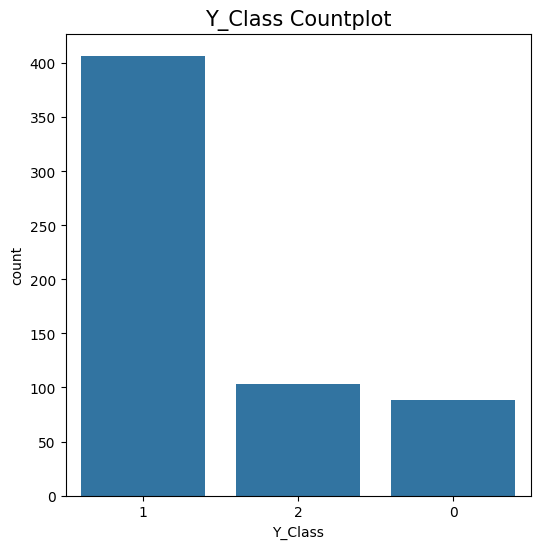

In [11]:
plt.figure(figsize=(6,6))
sns.countplot(x='Y_Class',data=train_df,order=train_df['Y_Class'].value_counts().index)
plt.xlabel('Y_Class',fontsize=10)
plt.title('Y_Class Countplot',fontsize=15)

Regression의 사용되는 Y_Quality의 분포

Text(0.5, 1.0, 'Y_Quality distribution')

<Figure size 1000x1000 with 0 Axes>

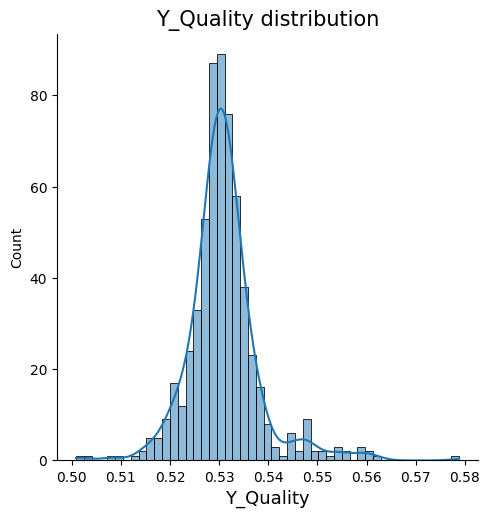

In [12]:
plt.figure(figsize=(10,10))
sns.displot(data=train_df,x='Y_Quality',kde=True)
plt.xlabel('Y_Quality',fontsize=13)
plt.title('Y_Quality distribution',fontsize=15)

여기서 시도해볼 수 있는 성능을 높히는 방법 
1. 시계열 데이터를 변환하여 사용가능한 Lable로 바꾸어 사용한다.
2. 데이터 속 로직을 찾아내어 모델에 맞게 변형하여 학습시켜준다.
3. 결측치 및 이상치를 찾아내어 정재하는 과정을 거쳐준다.

In [13]:
train_df.iloc[:,:10].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PRODUCT_ID    598 non-null    object 
 1   Y_Class       598 non-null    int64  
 2   Y_Quality     598 non-null    float64
 3   TIMESTAMP     598 non-null    object 
 4   LINE          598 non-null    object 
 5   PRODUCT_CODE  598 non-null    object 
 6   X_1           349 non-null    float64
 7   X_2           349 non-null    float64
 8   X_3           349 non-null    float64
 9   X_4           349 non-null    float64
dtypes: float64(5), int64(1), object(4)
memory usage: 46.8+ KB


In [14]:
train_df.isnull().sum()
train_df.describe(include='all')

,PRODUCT_ID,Y_Class,Y_Quality,TIMESTAMP,LINE,PRODUCT_CODE,X_1,X_2,X_3,X_4,...,X_2866,X_2867,X_2868,X_2869,X_2870,X_2871,X_2872,X_2873,X_2874,X_2875
count,598,598.000000,598.000000,598,598,598,349.000000,349.000000,349.0,349.0,...,100.000000,100.00000,100.000000,100.000000,100.00000,99.0,0.0,0.0,0.0,0.0
unique,598,NaN,NaN,598,6,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,TRAIN_000,NaN,NaN,2022-06-13 5:14,T100304,T_31,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,1,175,343,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.025084,0.530896,NaN,NaN,NaN,2.409742,95.123209,0.0,45.0,...,50.807300,53.60770,49.606200,51.659800,66.64970,1.0,NaN,NaN,NaN,NaN
std,NaN,0.565069,0.007401,NaN,NaN,NaN,5.895256,4.107640,0.0,0.0,...,7.011828,8.13899,7.158917,8.913065,4.52781,0.0,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.500856,NaN,NaN,NaN,1.000000,87.000000,0.0,45.0,...,32.120000,31.70000,32.560000,30.490000,61.67000,1.0,NaN,NaN,NaN,NaN
25%,NaN,1.000000,0.527535,NaN,NaN,NaN,2.000000,93.000000,0.0,45.0,...,49.485000,52.20000,42.160000,49.915000,63.64500,1.0,NaN,NaN,NaN,NaN
50%,NaN,1.000000,0.530436,NaN,NaN,NaN,2.000000,95.000000,0.0,45.0,...,53.425000,55.92500,51.460000,56.175000,65.14000,1.0,NaN,NaN,NaN,NaN
75%,NaN,1.000000,0.533433,NaN,NaN,NaN,2.000000,98.000000,0.0,45.0,...,55.287500,58.97500,55.030000,57.175000,67.11500,1.0,NaN,NaN,NaN,NaN


전부 결측치인 값을 제거하기로 함.

In [15]:
temp = []
all_null = pd.DataFrame(train_df.isnull().sum(),columns=['sum'])
temp = list(all_null[all_null['sum']==train_df.shape[0]].index)
train_df.drop(columns=temp,inplace=True)
test_df.drop(columns=temp, inplace=True)

In [16]:
train_df['TIMESTAMP'] = pd.to_datetime(train_df['TIMESTAMP'])
test_df['TIMESTAMP'] = pd.to_datetime(test_df['TIMESTAMP'])

train_df['hour'] = train_df['TIMESTAMP'].dt.hour
test_df['hour'] = test_df['TIMESTAMP'].dt.hour

train_df['day'] = train_df['TIMESTAMP'].dt.day
test_df['day'] = test_df['TIMESTAMP'].dt.day

train_df['minute'] = train_df['TIMESTAMP'].dt.minute
test_df['minute'] = test_df['TIMESTAMP'].dt.minute

train_df['month'] = train_df['TIMESTAMP'].dt.month
test_df['month'] = test_df['TIMESTAMP'].dt.month

https://dacon.io/competitions/official/236055/talkboard/407746?page=3&dtype=recent를 확인하면 새로운 로직을 발견할 수 있는 것이 LINE과 PRODUCT_CODE의 규칙을 확인 할 수 있는 것이 있으나 활용하려면 사용해야할듯

In [17]:
train_df['LINE_front'] = train_df['LINE'].str[1:3]
test_df['LINE_front'] = test_df['LINE'].str[1:3]

train_df['LINE_Back'] = train_df['LINE'].str[5:]
test_df['LINE_Back'] = test_df['LINE'].str[5:]

train_df['LINE_PRODUCT'] = train_df['LINE']+'-'+train_df['PRODUCT_CODE']
test_df['LINE_PRODUCT'] = test_df['LINE']+'-'+test_df['PRODUCT_CODE']

추가적으로 전부결측치인것을 제외한 결측치들은 0으로 입력 및 필요없는 변수 제거 

In [18]:
train_df = train_df.fillna(0)
test_df = test_df.fillna(0)

train_x2 = train_df.drop(['PRODUCT_ID','TIMESTAMP','Y_Class','Y_Quality'],axis=1)
train_y2 = train_df['Y_Class']
train_y2_r = train_df['Y_Quality']

test_x2 = test_df.drop(['PRODUCT_ID','TIMESTAMP','Y_Class','Y_Quality'], axis=1, errors='ignore')

In [19]:
qual_col = ['LINE', 'PRODUCT_CODE','LINE_PRODUCT']
def LabelEncoding(data, data2):
    for i in qual_col:
        le = LabelEncoder()
        le = le.fit(data[i])
        data[i] = le.transform(data[i])
        
        for label in np.unique(data2[i]): 
            if label not in le.classes_: 
                le.classes_ = np.append(le.classes_, label)
        data2[i] = le.transform(data2[i]) 
    for col in ["LINE_front", "LINE_Back"]:
        data[col] = le.fit_transform(data[col].astype(str))
    for col in ["LINE_front", "LINE_Back"]:
        data2[col] = le.fit_transform(data2[col].astype(str))
    return data, data2
LabelEncoding(train_x2, test_x2)
print(train_x2.head())
print(test_x2.head())    

   LINE  PRODUCT_CODE  X_1  X_2  X_3  X_4  X_5  X_6  X_7  X_8  ...  X_2869  \
0     2             0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   34.09   
1     3             0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   35.34   
2     2             0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   36.53   
3     3             0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   30.58   
4     2             0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   33.09   

   X_2870  X_2871  hour  day  minute  month  LINE_front  LINE_Back  \
0   77.77     0.0     5   13      14      6           1          0   
1   72.55     0.0     5   13      22      6           1          3   
2   78.35     0.0     5   13      30      6           1          0   
3   71.78     0.0     5   13      39      6           1          3   
4   76.97     0.0     5   13      47      6           1          0   

   LINE_PRODUCT  
0             2  
1             3  
2             2  
3             3  
4             2  

[

Y_Quality로 회귀모델 성능 시험해보기

In [20]:
train_x2_r, val_x_r, train_y2_r, val_y_r = train_test_split(train_x2, train_y2_r, test_size=0.25, shuffle=True, random_state=42)
lr = LinearRegression(n_jobs=-1)
lr.fit(train_x2_r, train_y2_r)
lr_predict = lr.predict(val_x_r)
mse = mean_squared_error(val_y_r , lr_predict)
mae = mean_absolute_error(val_y_r, lr_predict)
rmse = root_mean_squared_error(val_y_r, lr_predict)

print("mse:",mse)
print("mae:",mae)
print("rmse:",rmse)

mse: 0.00010064882333918961
mae: 0.006593593554973972
rmse: 0.010032388715514845


회귀 모델은 힘든거 같음 ppt에 안써도 될지도 쓴다면 선형회귀로 하면 Lable이 너무 많아 과적합이 되는거 같은 내용을 적어야 할듯

In [21]:
train_x3, val_x, train_y3, val_y = train_test_split(train_x2, train_y2, test_size=0.25, shuffle=True, random_state=42)
model1 = AdaBoostClassifier(random_state=42)
model1.fit(train_x3, train_y3)

model2 = XGBClassifier()
model2.fit(train_x3, train_y3)

model3 =  RandomForestClassifier(random_state=42)
model3.fit(train_x3, train_y3)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
pred1 = model1.predict(val_x)

pred2 = model2.predict(val_x)

pred3 = model3.predict(val_x)

def evaluate(name,y_true, y_pred):
    print(name)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall   :", recall_score(y_true, y_pred, average='macro'))
    print("F1-score :", f1_score(y_true, y_pred, average='macro'))
evaluate("AdaBoost", val_y, pred1)
evaluate("XGBoost", val_y, pred2)
evaluate("RandomForest", val_y, pred3)

AdaBoost
Accuracy : 0.68
Precision: 0.5737595737595738
Recall   : 0.46070692194403534
F1-score : 0.47773038268499274
XGBoost
Accuracy : 0.7266666666666667
Precision: 0.7173509286412513
Recall   : 0.5398576337751595
F1-score : 0.5783559577677224
RandomForest
Accuracy : 0.7333333333333333
Precision: 0.7578570156695156
Recall   : 0.536254295532646
F1-score : 0.5771202781729098


In [23]:
from sklearn.ensemble import VotingClassifier
vo_clf1=VotingClassifier(estimators=[('Ada',model1),('XGB',model2),('RF',model3)],voting='hard')
vo_clf1.fit(train_x3, train_y3)
pred4 = vo_clf1.predict(val_x)
evaluate("VotingClassifier", val_y, pred4)

VotingClassifier
Accuracy : 0.6933333333333334
Precision: 0.7144581457558558
Recall   : 0.4789052528227786
F1-score : 0.5044719642242862


In [24]:
from sklearn.ensemble import VotingClassifier
vo_clf2=VotingClassifier(estimators=[('Ada',model1),('XGB',model2),('RF',model3)],voting='soft')
vo_clf2.fit(train_x3, train_y3)
pred5 = vo_clf2.predict(val_x)
evaluate("VotingClassifier", val_y, pred5)

VotingClassifier
Accuracy : 0.74
Precision: 0.746031746031746
Recall   : 0.5467304860088366
F1-score : 0.5901890679917585


균형있게 잘예측하고있는 소프트방식이 좋아보임

In [25]:
Y = vo_clf2.predict(test_x2)
submit = pd.read_csv('./sample_submission.csv')
submit['Y_Class'] = Y
submit.to_csv('./submission.csv', index=False)